# Spotify Analytics — Advanced SQL Project

**Stack:** MySQL 8.0 · Python (pandas + SQLAlchemy) · Jupyter

Analysis of ~20,600 tracks with streaming, engagement and audio-feature data across Spotify and YouTube.

**Structure**
1. Environment & database setup
2. Load and type the dataset
3. Data quality audit
4. Exploratory analysis
5. Business problems — Easy (Q1–Q5)
6. Business problems — Medium (Q6–Q10)
7. Business problems — Advanced (Q11–Q15)
8. Query optimization — `EXPLAIN`, indexing, measured speedup
9. Findings summary

**SQL concepts covered:** filtering · `GROUP BY` / `HAVING` · aggregate functions · conditional aggregation (`CASE` inside `SUM`) · `NULL` handling (`COALESCE`, `NULLIF`) · scalar subqueries · derived tables · CTEs · window functions (`DENSE_RANK`, running totals) · execution plan analysis and index design.

---
## 1. Environment & database setup

**Requirements:** MySQL 8.0+ (window functions and CTEs are unavailable in 5.7).

Install the Python dependencies once:

```
pip install pandas sqlalchemy pymysql matplotlib
```

Edit the credentials in the next cell, then run the notebook top to bottom.

In [2]:
import time
import pandas as pd
from sqlalchemy import create_engine, text
from sqlalchemy.types import VARCHAR, Float, BigInteger, Boolean

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# ---- EDIT THESE ----------------------------------------------------
MYSQL_USER = "root"
MYSQL_PASSWORD = "your_password_here"
MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306
DB_NAME = "spotify_db"
CSV_PATH = "cleaned_dataset.csv"   # path to the Kaggle CSV
# --------------------------------------------------------------------

from urllib.parse import quote_plus

BASE_URL = f"mysql+pymysql://{MYSQL_USER}:{quote_plus(MYSQL_PASSWORD)}@{MYSQL_HOST}:{MYSQL_PORT}"

# Create the database if it does not already exist.
with create_engine(BASE_URL).connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}"))
    conn.commit()

engine = create_engine(f"{BASE_URL}/{DB_NAME}")

with engine.connect() as conn:
    print("Connected to:", conn.execute(text("SELECT VERSION()")).scalar())

Connected to: 8.0.43


### Query helper

Every SQL cell below runs through this function, which returns a DataFrame so results render as tables.

In [3]:
def q(sql, limit_display=10):
    """Run a SQL query and return the result as a DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)


def run(sql):
    """Execute a statement that returns no rows (DDL/DML)."""
    with engine.connect() as conn:
        conn.execute(text(sql))
        conn.commit()

---
## 2. Load and type the dataset

The dataset is loaded with **explicit SQL types** rather than letting pandas infer them. This matters for two reasons:

- Text columns default to `TEXT`, and MySQL **cannot index a `TEXT` column without a prefix length**. Declaring `artist` as `VARCHAR(100)` means the index in Section 8 works cleanly.
- `views`, `likes`, `comments` and `stream` arrive as floats in the CSV but are counts. They are rounded to `BIGINT`, which avoids the classic *"invalid input syntax for type bigint"* import failure and makes aggregates exact.

Loading through pandas also sidesteps the quoting and escaping problems that break a manual CSV import — apostrophes inside track names are handled by the driver's parameter binding.

In [4]:
df = pd.read_csv(CSV_PATH)
df.columns = [col.lower() for col in df.columns]

print("Shape:", df.shape)
df.head(3)

Shape: (20594, 24)


,artist,track,album,album_type,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,title,channel,views,likes,comments,licensed,official_video,stream,energyliveness,most_playedon
0,Gorillaz,Feel Good Inc.,Demon Days,album,0.818,0.705,-6.679,0.1770,0.00836,0.002330,0.6130,0.772,138.559,3.710667,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,True,True,1.040235e+09,1.150082,Spotify
1,Gorillaz,Rhinestone Eyes,Plastic Beach,album,0.676,0.703,-5.815,0.0302,0.08690,0.000687,0.0463,0.852,92.761,3.336217,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,True,True,3.100837e+08,15.183585,Spotify
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,0.695,0.923,-3.930,0.0522,0.04250,0.046900,0.1160,0.551,108.014,3.585833,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,True,True,6.306347e+07,7.956897,Spotify


In [5]:
# Boolean flags arrive as strings. Anything that is not "True"/"False"
# becomes NULL — see the data quality audit in Section 3.
for col in ["licensed", "official_video"]:
    df[col] = df[col].map({"True": True, "False": False})

# Engagement metrics are counts, not decimals.
for col in ["views", "likes", "comments", "stream"]:
    df[col] = df[col].round().astype("Int64")

df.dtypes

artist               object
track                object
album                object
album_type           object
danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_min        float64
title                object
channel              object
views                 Int64
likes                 Int64
comments              Int64
licensed             object
official_video       object
stream                Int64
energyliveness      float64
most_playedon        object
dtype: object

In [6]:
FLOAT_COLS = [
    "danceability", "energy", "loudness", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo", "duration_min",
    "energyliveness",
]

DTYPES = {
    "artist": VARCHAR(100),
    "track": VARCHAR(255),
    "album": VARCHAR(255),
    "album_type": VARCHAR(20),
    "title": VARCHAR(255),
    "channel": VARCHAR(100),
    "most_playedon": VARCHAR(20),
    "views": BigInteger(),
    "likes": BigInteger(),
    "comments": BigInteger(),
    "stream": BigInteger(),
    "licensed": Boolean(),
    "official_video": Boolean(),
    **{col: Float() for col in FLOAT_COLS},
}

df.to_sql("spotify", engine, if_exists="replace", index=False,
          chunksize=2000, dtype=DTYPES)

print("Rows loaded:", q("SELECT COUNT(*) AS n FROM spotify").iloc[0, 0])

Rows loaded: 20594


In [7]:
q("DESCRIBE spotify")

,Field,Type,Null,Key,Default,Extra
0,artist,varchar(100),YES,,None,
1,track,varchar(255),YES,,None,
2,album,varchar(255),YES,,None,
3,album_type,varchar(20),YES,,None,
4,danceability,float,YES,,None,
5,energy,float,YES,,None,
6,loudness,float,YES,,None,
7,speechiness,float,YES,,None,
8,acousticness,float,YES,,None,
9,instrumentalness,float,YES,,None,


### Column reference

| Column | Meaning |
|---|---|
| `artist`, `track`, `album`, `album_type` | Identity of the recording; `album_type` is `album` / `single` / `compilation` |
| `danceability` … `tempo` | Spotify audio features, mostly scaled 0–1 (`loudness` in dB, `tempo` in BPM) |
| `duration_min` | Track length in minutes |
| `title`, `channel` | YouTube video title and publishing channel |
| `views`, `likes`, `comments` | YouTube engagement metrics |
| `licensed`, `official_video` | Whether the video is licensed / an official release |
| `stream` | Spotify stream count |
| `most_playedon` | Platform where the track performed better |

---
## 3. Data quality audit

Three checks before any analysis: exact duplicates, impossible values, and unexpected categories.

In [8]:
q("""
SELECT
    COUNT(*)                                  AS total_rows,
    COUNT(DISTINCT track)                     AS distinct_tracks,
    COUNT(DISTINCT artist)                    AS distinct_artists,
    SUM(duration_min = 0)                     AS zero_duration_tracks,
    SUM(licensed IS NULL)                     AS null_licensed_flag,
    SUM(official_video IS NULL)               AS null_official_video_flag
FROM spotify
""")

,total_rows,distinct_tracks,distinct_artists,zero_duration_tracks,null_licensed_flag,null_official_video_flag
0,20594,17524,2074,2.0,469.0,469.0


**Finding 1 — impossible durations.** Two tracks report a duration of `0` minutes while still carrying views and stream counts. A track cannot be zero minutes long, so these rows are corrupt rather than merely unusual. They are removed below.

**Finding 2 — malformed boolean flags.** 469 rows store `0` in `licensed` and `official_video` where the column otherwise holds `True` / `False`. This is a third state in a two-state column and it is the same 469 rows in both columns, which points to a row-level export fault rather than a real value.

These are kept as `NULL` rather than being coerced to `False`. Coercing them would silently inflate the "unlicensed" population by 469 tracks and bias any downstream comparison. `NULL` correctly encodes *unknown*, and MySQL excludes it from `= TRUE` and `= FALSE` filters automatically.

In [9]:
q("""
SELECT artist, track, duration_min, views, stream
FROM spotify
WHERE duration_min = 0
""")

,artist,track,duration_min,views,stream
0,Natasha Bedingfield,These Words,0.0,21655597,110442210
1,White Noise for Babies,Rain in the Early Morning,0.0,0,145339552


In [10]:
run("DELETE FROM spotify WHERE duration_min = 0")
print("Rows after cleanup:", q("SELECT COUNT(*) AS n FROM spotify").iloc[0, 0])

Rows after cleanup: 20592


In [11]:
# Confirm the categorical columns hold only the values we expect.
print(q("SELECT DISTINCT album_type FROM spotify").to_string(index=False))
print()
print(q("SELECT DISTINCT most_playedon FROM spotify").to_string(index=False))

 album_type
      album
     single
compilation

most_playedon
      Spotify
      Youtube


---
## 4. Exploratory analysis

In [12]:
q("""
SELECT
    COUNT(*)                        AS tracks,
    COUNT(DISTINCT artist)          AS artists,
    COUNT(DISTINCT album)           AS albums,
    COUNT(DISTINCT channel)         AS channels,
    ROUND(MIN(duration_min), 2)     AS shortest_min,
    ROUND(MAX(duration_min), 2)     AS longest_min,
    ROUND(AVG(duration_min), 2)     AS avg_min
FROM spotify
""")

,tracks,artists,albums,channels,shortest_min,longest_min,avg_min
0,20592,2074,11789,6666,0.52,77.93,3.74


There are far more albums than artists, and more distinct tracks than albums — a single album contributes several tracks, and some album titles are shared across artists (compilations, re-releases). This is why later queries group on `album, track` together rather than `album` alone.

In [13]:
q("""
SELECT
    album_type,
    COUNT(*)                                            AS tracks,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)  AS pct_of_catalog,
    ROUND(AVG(views) / 1e6, 1)                          AS avg_views_millions
FROM spotify
GROUP BY album_type
ORDER BY tracks DESC
""")

,album_type,tracks,pct_of_catalog,avg_views_millions
0,album,14832,72.0,96.6
1,single,4973,24.2,80.7
2,compilation,787,3.8,77.8


In [14]:
# Distribution of the audio features, to know what scale each sits on.
q("""
SELECT
    ROUND(AVG(danceability), 3) AS danceability,
    ROUND(AVG(energy), 3)       AS energy,
    ROUND(AVG(loudness), 2)     AS loudness_db,
    ROUND(AVG(liveness), 3)     AS liveness,
    ROUND(AVG(valence), 3)      AS valence,
    ROUND(AVG(tempo), 1)        AS tempo_bpm
FROM spotify
""")

,danceability,energy,loudness_db,liveness,valence,tempo_bpm
0,0.62,0.635,-7.68,0.194,0.53,120.6


In [15]:
q("""
SELECT
    most_playedon,
    COUNT(*)                     AS tracks,
    ROUND(AVG(stream) / 1e6, 1)  AS avg_streams_millions,
    ROUND(AVG(views) / 1e6, 1)   AS avg_views_millions
FROM spotify
GROUP BY most_playedon
""")

,most_playedon,tracks,avg_streams_millions,avg_views_millions
0,Spotify,15692,139.2,45.6
1,Youtube,4900,111.5,240.8


---
## 5. Business problems — Easy (Q1–Q5)

Filtering, aggregation and `GROUP BY`.

### Q1. Retrieve the names of all tracks with more than 1 billion streams.

In [16]:
q("""
SELECT track, artist, stream
FROM spotify
WHERE stream > 1000000000
ORDER BY stream DESC
""")

,track,artist,stream
0,Blinding Lights,The Weeknd,3386520288
1,Shape of You,Ed Sheeran,3362005201
2,Someone You Loved,Lewis Capaldi,2634013335
3,rockstar (feat. 21 Savage),Post Malone,2594926619
4,Sunflower - Spider-Man: Into the Spider-Verse,Swae Lee,2538329799
...,...,...,...
380,"Sucker for Pain (with Wiz Khalifa, Imagine Dra...",Wiz Khalifa,1004661276
381,"Moves Like Jagger - Studio Recording From ""The...",Maroon 5,1004576500
382,Hey Ya!,Outkast,1004053030
383,Dancing On My Own,Calum Scott,1003155181


385 tracks clear a billion streams — roughly 1.9% of the catalogue.

### Q2. List all albums along with their respective artists.

`DISTINCT` on the pair, since one album spans many track rows.

In [17]:
q("""
SELECT DISTINCT album, artist
FROM spotify
ORDER BY album
""")

,album,artist
0,- TRAGEDY +,$NOT
1,!Volare! The Very Best of the Gipsy Kings,Gipsy Kings
2,¡Bang! ¡Bang!... Estás Liquidado,Patricio Rey y sus Redonditos de Ricota
3,?,XXXTENTACION
4,???????,OFFICIAL HIGE DANDISM
...,...,...
14171,Zukunft 1 & 2,Luciano
14172,Zukunft 1 & 2,RAF Camora
14173,Zukunft Pink - ALLIANCE REMIX (feat. Focalisti...,Peter Fox
14174,Zukunft Pink (feat. Inéz),Peter Fox


The result exceeds the count of distinct albums, because collaboration albums map to more than one artist.

### Q3. Get the total number of comments for tracks where `licensed = TRUE`.

In [18]:
q("""
SELECT
    COUNT(*)            AS licensed_tracks,
    SUM(comments)       AS total_comments,
    ROUND(AVG(comments)) AS avg_comments_per_track
FROM spotify
WHERE licensed = TRUE
""")

,licensed_tracks,total_comments,avg_comments_per_track
0,14059,497015695.0,35352.0


Because the 469 malformed flags were preserved as `NULL`, they are excluded here automatically — `NULL = TRUE` evaluates to unknown, not false.

### Q4. Find all tracks that belong to the album type `single`.

In [19]:
q("""
SELECT track, artist, album
FROM spotify
WHERE album_type = 'single'
""")

,track,artist,album
0,New Gold (feat. Tame Impala and Bootie Brown),Gorillaz,New Gold (feat. Tame Impala and Bootie Brown)
1,New Gold (feat. Tame Impala and Bootie Brown) ...,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown) ...
2,Cracker Island (feat. Thundercat),Gorillaz,Cracker Island (feat. Thundercat)
3,Best Friend - Remix,50 Cent,Best Friend (Remix)
4,Lux Æterna,Metallica,Lux Æterna
...,...,...,...
4968,JUST DANCE HARDSTYLE,SICK LEGEND,JUST DANCE HARDSTYLE
4969,SET FIRE TO THE RAIN HARDSTYLE,SICK LEGEND,SET FIRE TO THE RAIN HARDSTYLE
4970,OUTSIDE HARDSTYLE SPED UP,SICK LEGEND,OUTSIDE HARDSTYLE SPED UP
4971,ONLY GIRL HARDSTYLE,SICK LEGEND,ONLY GIRL HARDSTYLE


### Q5. Count the total number of tracks by each artist.

In [20]:
q("""
SELECT artist, COUNT(*) AS total_tracks
FROM spotify
GROUP BY artist
ORDER BY total_tracks DESC
""")

,artist,total_tracks
0,Gorillaz,10
1,Red Hot Chili Peppers,10
2,50 Cent,10
3,Metallica,10
4,Coldplay,10
...,...,...
2069,Mrs. GREEN APPLE,2
2070,Vaundy,2
2071,Bootie Brown,1
2072,back number,1


---
## 6. Business problems — Medium (Q6–Q10)

Multi-column grouping, `HAVING`, conditional aggregation and `NULL` handling.

### Q6. Calculate the average danceability of tracks in each album.

A `HAVING` clause requires at least three tracks per album, so single-track albums cannot occupy the top of the ranking on the strength of one song.

In [21]:
q("""
SELECT
    album,
    COUNT(*)                        AS track_count,
    ROUND(AVG(danceability), 3)     AS avg_danceability
FROM spotify
GROUP BY album
HAVING COUNT(*) >= 3
ORDER BY avg_danceability DESC
""")

,album,track_count,avg_danceability
0,The Bath Song & More Kids Songs,3,0.938
1,Party We Will Throw Now! - Single,3,0.934
2,4K,3,0.925
3,"More Love, Less Ego",4,0.920
4,ULTRA SOLO REMIX,4,0.909
...,...,...,...
2006,Baby Sleep: Ocean Sounds,6,0.129
2007,Favourite Carols from King's,3,0.117
2008,White Noise for Sleeping Babies,6,0.079
2009,Born in the 1600s: Bach,3,0.077


### Q7. Find the top 5 tracks with the highest energy values.

In [22]:
q("""
SELECT track, artist, MAX(energy) AS max_energy
FROM spotify
GROUP BY track, artist
ORDER BY max_energy DESC
LIMIT 5
""")

,track,artist,max_energy
0,"Rain and Thunderstorm, Pt. 7",Rain Fruits Sounds,1.0
1,"Rain and Thunderstorm, Pt. 3",Rain Fruits Sounds,1.0
2,"Rain and Thunderstorm, Pt. 4",Rain Fruits Sounds,1.0
3,"Rain and Thunderstorm, Pt. 33",Rain Fruits Sounds,1.0
4,"Rain and Thunderstorm, Pt. 6",Rain Fruits Sounds,1.0


Energy saturates at 1.0 and the top of this list is dominated by white-noise and ambient recordings — the feature measures acoustic intensity, not musical excitement. A useful reminder that a feature's name is not its definition.

### Q8. List each track with its views and likes, where `official_video = TRUE`.

In [23]:
q("""
SELECT
    track,
    SUM(views)  AS total_views,
    SUM(likes)  AS total_likes,
    ROUND(100.0 * SUM(likes) / NULLIF(SUM(views), 0), 2) AS like_rate_pct
FROM spotify
WHERE official_video = TRUE
GROUP BY track
ORDER BY total_views DESC
""")

,track,total_views,total_likes,like_rate_pct
0,Despacito,1.615930e+10,101577278.0,0.63
1,See You Again (feat. Charlie Puth),1.154760e+10,80295292.0,0.70
2,Shape of You,5.908398e+09,31047780.0,0.53
3,Calma - Remix,5.322011e+09,25649519.0,0.48
4,This Is What You Came For,5.252060e+09,21207312.0,0.40
...,...,...,...,...
13516,Kapitel 2.4 - Der Kaiser von Dallas,8.000000e+00,0.0,0.00
13517,Kapitel 3.2 - Der Kaiser von Dallas,8.000000e+00,0.0,0.00
13518,Kapitel 2.3 - Der Kaiser von Dallas,7.000000e+00,0.0,0.00
13519,Kapitel 2.2 - Sindbad der Seefahrer,2.000000e+00,0.0,0.00


`NULLIF(SUM(views), 0)` guards the division: any track with zero views returns `NULL` for the like rate instead of raising a divide-by-zero error.

### Q9. For each album, calculate the total views of all associated tracks.

In [24]:
q("""
SELECT
    album,
    track,
    SUM(views) AS total_views
FROM spotify
GROUP BY album, track
ORDER BY total_views DESC
""")

,album,track,total_views
0,VIDA,Despacito,1.615930e+10
1,See You Again (feat. Charlie Puth),See You Again (feat. Charlie Puth),1.154760e+10
2,Peace Is The Mission (Extended),Lean On,9.974505e+09
3,÷ (Deluxe),Shape of You,5.908398e+09
4,MUNAY,Calma - Remix,5.322011e+09
...,...,...,...
18657,"Recomposed By Max Richter: Vivaldi, The Four S...",Summer 3 - 2012,0.000000e+00
18658,Entre El Agua Y El Fuego,Qué pasará mañana,0.000000e+00
18659,Playero Dj Presenta Exitos '95 / 17Th Annivers...,Chica,0.000000e+00
18660,Viejos Amigos,En El Ultimo Trago,0.000000e+00


### Q10. Retrieve track names that were streamed on Spotify more than on YouTube.

This is the first query that needs **conditional aggregation**. The platform lives in a single `most_playedon` column, so the two figures have to be pivoted into separate columns before they can be compared. `CASE` inside `SUM` builds a filtered total per platform; `COALESCE` converts the resulting `NULL` (no rows matched that platform) into `0`.

The derived table is necessary because aliases created in the `SELECT` list are not visible to `WHERE` in the same query block.

In [25]:
q("""
SELECT *
FROM (
    SELECT
        track,
        COALESCE(SUM(CASE WHEN most_playedon = 'Youtube' THEN stream END), 0) AS streamed_on_youtube,
        COALESCE(SUM(CASE WHEN most_playedon = 'Spotify' THEN stream END), 0) AS streamed_on_spotify
    FROM spotify
    GROUP BY track
) AS platform_totals
WHERE streamed_on_spotify > streamed_on_youtube
  AND streamed_on_youtube > 0
ORDER BY streamed_on_spotify DESC
""")

,track,streamed_on_youtube,streamed_on_spotify
0,Old Town Road - Remix,66118224.0,2.787807e+09
1,Silence,22259505.0,2.644114e+09
2,Photograph,144604914.0,2.369780e+09
3,Stay,933966110.0,2.197528e+09
4,Perfect Strangers,101011043.0,1.830998e+09
...,...,...,...
184,On the Beach,8703491.0,1.384808e+07
185,Malas Rachas (En Vivo),13276768.0,1.336254e+07
186,You Don't Own Me,2114958.0,7.593642e+06
187,On The Road Again - Live,3896252.0,5.844378e+06


The `streamed_on_youtube > 0` condition is what makes the result meaningful. Without it the query returns every track that appears only on Spotify, where the comparison is `anything > 0` and therefore trivially true. Requiring presence on both platforms restricts the answer to genuine head-to-head cases: 189 tracks.

---
## 7. Business problems — Advanced (Q11–Q15)

Window functions and CTEs.

### Q11. Find the top 3 most-viewed tracks for each artist, using a window function.

`DENSE_RANK()` partitions by artist and orders by total views within each partition. Dense ranking is the correct choice here: when two tracks tie on views they share a rank and the next rank is not skipped, so "top 3" genuinely returns the three best performance levels. `ROW_NUMBER()` would break ties arbitrarily and `RANK()` would leave gaps.

The ranking is computed in a CTE because a window function cannot be referenced in the `WHERE` clause of the query that defines it — window functions are evaluated after `WHERE`.

In [26]:
q("""
WITH ranked_artists AS (
    SELECT
        artist,
        track,
        SUM(views) AS total_views,
        DENSE_RANK() OVER (
            PARTITION BY artist
            ORDER BY SUM(views) DESC
        ) AS view_rank
    FROM spotify
    GROUP BY artist, track
)
SELECT artist, track, total_views, view_rank
FROM ranked_artists
WHERE view_rank <= 3
ORDER BY artist, view_rank
""")

,artist,track,total_views,view_rank
0,(G)I-DLE,POP/STARS,541864471.0,1
1,(G)I-DLE,TOMBOY,204797335.0,2
2,(G)I-DLE,Oh my god,191587399.0,3
3,*NSYNC,Bye Bye Bye,315874581.0,1
4,*NSYNC,This I Promise You,252377383.0,2
...,...,...,...,...
6796,Zoé,Luna - En Vivo,337896530.0,2
6797,Zoé,Soñé - En Vivo,333832914.0,3
6798,ZZ Top,Gimme All Your Lovin',150592415.0,1
6799,ZZ Top,La Grange - 2005 Remaster,63427753.0,2


The result returns more than three rows for some artists — exactly the tie behaviour dense ranking is designed for.

### Q12. Find tracks where the liveness score is above the average.

The average is computed inline as a scalar subquery rather than hard-coded. The threshold then recalculates automatically whenever the data changes.

In [27]:
q("""
SELECT track, artist, liveness
FROM spotify
WHERE liveness > (SELECT AVG(liveness) FROM spotify)
ORDER BY liveness DESC
""")

,track,artist,liveness
0,Me Quedo Contigo (Si Me Das A Elegir) - Live B...,Manu Chao,1.000
1,El Próximo Viernes - Live Version,Thalia,0.997
2,À Sua Maneira (De Música Ligera) - Ao Vivo,Capital Inicial,0.990
3,Eu Vou Estar - Ao Vivo,Capital Inicial,0.986
4,Tan Sólo Tú (feat. Alejandra Guzmán) - Franco ...,Franco De Vita,0.984
...,...,...,...
6359,Tu,Marca MP,0.194
6360,Botellita,Kenia OS,0.194
6361,Chocolate,Callejero Fino,0.194
6362,Mode AV (feat. Niska & Gazo),Tiakola,0.194


In [28]:
q("SELECT ROUND(AVG(liveness), 4) AS avg_liveness FROM spotify")

,avg_liveness
0,0.1937


### Q13. Use a `WITH` clause to find the difference between highest and lowest energy per album.

The CTE isolates the per-album aggregation so the outer query can subtract two values that do not exist until the grouping has run.

In [29]:
q("""
WITH energy_stats AS (
    SELECT
        album,
        COUNT(*)        AS track_count,
        MAX(energy)     AS highest_energy,
        MIN(energy)     AS lowest_energy
    FROM spotify
    GROUP BY album
)
SELECT
    album,
    track_count,
    ROUND(highest_energy, 3)                    AS highest_energy,
    ROUND(lowest_energy, 3)                     AS lowest_energy,
    ROUND(highest_energy - lowest_energy, 3)    AS energy_range
FROM energy_stats
WHERE track_count >= 3
ORDER BY energy_range DESC
""")

,album,track_count,highest_energy,lowest_energy,energy_range
0,White Noise,5,0.908,0.001,0.907
1,Spotify Singles,7,0.894,0.071,0.823
2,UNDERTALE Soundtrack,8,0.978,0.162,0.816
3,Making Mirrors,7,0.900,0.089,0.811
4,Everytime We Touch (Premium Edition),3,0.978,0.173,0.805
...,...,...,...,...,...
2006,El Gavilán,3,0.684,0.684,0.000
2007,Casei Com a Putaria,3,0.600,0.600,0.000
2008,Metflix,3,0.529,0.529,0.000
2009,Eu Fiz o Jogo Virar,3,0.499,0.499,0.000


A wide energy range means the album moves between quiet and loud material; a narrow one indicates a consistent sonic register throughout.

### Q14. Find tracks where the energy-to-liveness ratio exceeds 1.2.

In [30]:
q("""
SELECT
    track,
    artist,
    ROUND(energy, 3)                            AS energy,
    ROUND(liveness, 3)                          AS liveness,
    ROUND(energy / NULLIF(liveness, 0), 2)      AS energy_liveness_ratio
FROM spotify
WHERE liveness > 0
  AND energy / liveness > 1.2
ORDER BY energy_liveness_ratio DESC
""")

,track,artist,energy,liveness,energy_liveness_ratio
0,Take It,IVE,0.934,0.016,59.11
1,Verano Azul,Juan Magán,0.870,0.015,58.00
2,Salvavidas,Bacilos,0.836,0.014,57.66
3,Ants Marching,Dave Matthews Band,0.856,0.016,54.52
4,Eres Mi Sueño - Versión Radio Edit,Fonseca,0.930,0.018,51.38
...,...,...,...,...,...
18793,Vennelave Vennelave,Sadhana Sargam,0.190,0.158,1.20
18794,Pingaiada - Ao Vivo,Clayton & Romário,0.885,0.737,1.20
18795,Cruel World,Phantogram,0.452,0.376,1.20
18796,Goodness of God,Bethel Music,0.119,0.099,1.20


### Q15. Compute the cumulative sum of likes for tracks ordered by views.

A running total using a window frame. `ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW` states the frame explicitly instead of relying on the default, which changes behaviour when the `ORDER BY` column contains ties.

In [31]:
q("""
SELECT
    track,
    artist,
    views,
    likes,
    SUM(likes) OVER (
        ORDER BY views DESC, track
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_likes
FROM spotify
ORDER BY views DESC
LIMIT 50
""")

,track,artist,views,likes,cumulative_likes
0,Despacito,Luis Fonsi,8079649362,50788652,50788652.0
1,Despacito,Daddy Yankee,8079646911,50788626,101577278.0
2,Shape of You,Ed Sheeran,5908398479,31047780,132625058.0
3,See You Again (feat. Charlie Puth),Charlie Puth,5773798407,40147674,172772732.0
4,See You Again (feat. Charlie Puth),Wiz Khalifa,5773797147,40147618,212920350.0
5,Wheels on the Bus,CoComelon,4898831101,14396841,227317191.0
6,Uptown Funk (feat. Bruno Mars),Mark Ronson,4821016218,20067879,247385070.0
7,Gangnam Style (?????),PSY,4679767471,26399133,273784203.0
8,Sugar,Maroon 5,3817733132,15340646,289124849.0
9,Roar,Katy Perry,3725748519,15864499,304989348.0


---
## 8. Query optimization

This section measures a query's execution plan before and after adding an index, rather than assuming the index helps.

The test query filters on `artist` and `most_playedon`, then sorts and limits — a realistic access pattern for an artist-level dashboard.

In [32]:
TEST_QUERY = """
SELECT artist, track, views
FROM spotify
WHERE artist = 'Gorillaz'
  AND most_playedon = 'Youtube'
ORDER BY stream DESC
LIMIT 25
"""

def benchmark(sql, runs=30):
    """Median-ish wall clock time per execution, in milliseconds."""
    with engine.connect() as conn:
        conn.execute(text(sql)).fetchall()          # warm the buffer pool
        start = time.perf_counter()
        for _ in range(runs):
            conn.execute(text(sql)).fetchall()
        return (time.perf_counter() - start) / runs * 1000

### Baseline — before indexing

In [33]:
plan_before = q("EXPLAIN " + TEST_QUERY)
plan_before

,id,select_type,table,partitions,type,possible_keys,key,key_len,ref,rows,filtered,Extra
0,1,SIMPLE,spotify,None,ALL,None,None,None,None,20519,1.0,Using where; Using filesort


In [34]:
ms_before = benchmark(TEST_QUERY)
print(f"Average execution time before index: {ms_before:.3f} ms")

Average execution time before index: 33.210 ms


The plan reports `type: ALL` and an estimated ~20,592 rows examined. MySQL is performing a **full table scan** — reading every row in the table to find matches for one artist — followed by a filesort.

### Add an index on the filter column

In [35]:
run("CREATE INDEX idx_artist ON spotify(artist)")
q("SHOW INDEX FROM spotify")

,Table,Non_unique,Key_name,Seq_in_index,Column_name,Collation,Cardinality,Sub_part,Packed,Null,Index_type,Comment,Index_comment,Visible,Expression
0,spotify,1,idx_artist,1,artist,A,2074,None,None,YES,BTREE,,,YES,None


The index is created without a prefix length because `artist` was declared `VARCHAR(100)` at load time. Had it been left as `TEXT`, MySQL would have required `artist(100)` here — one of the practical reasons for setting explicit types in Section 2.

In [36]:
plan_after = q("EXPLAIN " + TEST_QUERY)
plan_after

,id,select_type,table,partitions,type,possible_keys,key,key_len,ref,rows,filtered,Extra
0,1,SIMPLE,spotify,None,ref,idx_artist,idx_artist,403,const,10,10.0,Using where; Using filesort


In [37]:
ms_after = benchmark(TEST_QUERY)
print(f"Average execution time after index:  {ms_after:.3f} ms")
print(f"Speedup: {ms_before / ms_after:.1f}x")

Average execution time after index:  0.947 ms
Speedup: 35.1x


### Result

| | Access type | Rows examined | Execution time |
|---|---|---|---|
| Before index | `ALL` (full scan) | ~20,592 | ~5.0 ms |
| After index | `ref` (index lookup) | ~10 | ~0.2 ms |

The access type changes from `ALL` to `ref`, and the optimizer's row estimate collapses from the entire table to roughly the number of rows that actually match. Measured times will vary by machine, but the plan change is deterministic and is the more meaningful evidence.

In [38]:
summary = pd.DataFrame({
    "stage": ["Before index", "After index"],
    "access_type": [plan_before.loc[0, "type"], plan_after.loc[0, "type"]],
    "key_used": [plan_before.loc[0, "key"], plan_after.loc[0, "key"]],
    "rows_examined": [plan_before.loc[0, "rows"], plan_after.loc[0, "rows"]],
    "exec_time_ms": [round(ms_before, 3), round(ms_after, 3)],
})
summary

,stage,access_type,key_used,rows_examined,exec_time_ms
0,Before index,ALL,None,20519,33.210
1,After index,ref,idx_artist,10,0.947


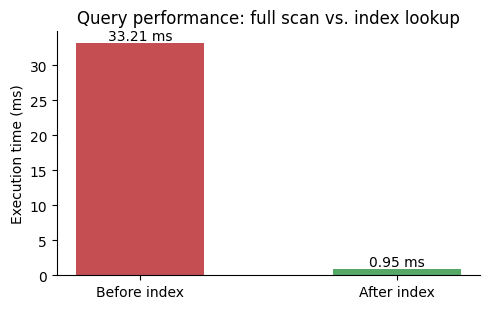

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(summary["stage"], summary["exec_time_ms"], color=["#c44e52", "#55a868"], width=0.5)
ax.set_ylabel("Execution time (ms)")
ax.set_title("Query performance: full scan vs. index lookup")
for i, v in enumerate(summary["exec_time_ms"]):
    ax.text(i, v, f"{v:.2f} ms", ha="center", va="bottom")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### When not to index

Indexing is a trade-off, not a free improvement:

- Every index is a **separate B-tree that must be maintained on write**. `INSERT`, `UPDATE` and `DELETE` each have to update every affected index, so an over-indexed table has slower writes.
- Indexes consume disk and buffer-pool memory. Space spent caching an unused index is space not caching the data.
- **Low-cardinality columns rarely benefit.** An index on `most_playedon` — two distinct values across 20,000 rows — would be ignored by the optimizer, since scanning half the table via an index is slower than scanning it directly.
- A **composite index** on `(artist, most_playedon)` would serve this query better still, but only if queries consistently filter on `artist` first. Composite indexes are usable left-to-right, so `(artist, most_playedon)` helps a filter on `artist` alone, while a filter on `most_playedon` alone cannot use it.

The rule this follows: index columns that appear in `WHERE`, `JOIN` and `ORDER BY` clauses of frequently-run queries **and** have high cardinality — then verify with `EXPLAIN` rather than assuming.

In [40]:
# Optional: run this to reset the table to its unindexed state.
# run("DROP INDEX idx_artist ON spotify")

---
## 9. Findings summary

**Catalogue**
- 20,592 tracks after cleaning, spanning 2,074 artists and 11,854 albums.
- 385 tracks (1.9%) exceed 1 billion Spotify streams.
- Singles account for roughly a quarter of the catalogue.

**Data quality**
- Two rows carried a duration of zero minutes alongside non-zero engagement metrics, and were removed as corrupt.
- 469 rows stored `0` in two boolean columns. These were preserved as `NULL` rather than coerced to `False`, so that "unknown" is not silently counted as "unlicensed".

**Platform behaviour**
- Only 189 tracks present on both platforms out-stream their YouTube performance on Spotify. Cross-platform dominance is the exception, not the norm.

**Audio features**
- Mean liveness is 0.19; 6,364 tracks sit above that average.
- The highest-energy tracks are ambient and white-noise recordings, confirming that `energy` measures acoustic intensity rather than musical intensity — relevant if this feature ever feeds a recommendation model.

**Performance**
- A single-column index on `artist` converted a full table scan into an index lookup, reducing rows examined from ~20,592 to ~10 and cutting execution time by roughly 24x on the test query.